# 03 · Count regression: Poisson vs negative binomial

**Question.** Given a municipality's fundamentals (who lives there, how they live, what is there), how many
public charging points would we *expect* it to have, and where does actual supply fall short?

**Model.** Count of public charging points per municipality, with population as exposure:

$$\log E[\text{points}_i] = \log(\text{population}_i) + \beta_0 + \sum_k \beta_k x_{ik}$$

so coefficients act on **points per resident**. The model is fitted as Poisson and as negative binomial (NB2);
the dispersion check decides which one to trust.

**How to read the output.** "Expected points" is what a typical municipality *in the Comunidad* with the same
characteristics has. It is a peer benchmark, not true demand: if the whole region is under-supplied, the model
cannot see that. Municipalities well below their expectation are the candidates `04_zone_scoring` ranks.

**Input:** `data/processed/features_municipal.csv` · **Outputs:** `data/processed/model_predictions.csv`,
`data/processed/model_coefficients.csv`

## 0 · Setup

In [13]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

if Path.cwd().name == "notebooks":
    os.chdir("..")
OUT = Path("data/processed")

feat = pd.read_csv(OUT / "features_municipal.csv", dtype={"ine_code": str})
print(f"{len(feat)} municipalities, {feat.shape[1]} columns")

# Chart style (light surface, recessive axes)
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE, CONTEXT = "#2a78d6", "#eb6834", "#b8b7b1"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
Path("maps").mkdir(exist_ok=True)

179 municipalities, 40 columns


## 1 · Response and predictors

Predictors are log-transformed (skewed ratios) and then **standardised**, so every coefficient reads as
"effect of a one-standard-deviation difference". `dist_nearest_public_km` is left out on purpose: it is
determined by the chargers themselves, so it would leak the answer into the model.

In [14]:
RESPONSE = "public_points"

# name in model -> (source column, transform)
PREDICTORS = {
    "income":    ("income_net_pp",          np.log),     # purchasing power
    "density":   ("pop_density_km2",        np.log),     # apartment living / no private garage
    "evs":       ("evs_per_1k_pop_adj",     np.log1p),   # resident EVs (fleet-corrected)
    "retail":    ("retail_per_10k_pop",     np.log1p),   # destination charging
    "office":    ("office_per_10k_pop",     np.log1p),   # workplace charging
    "transit":   ("transit_per_10k_pop",    np.log1p),   # park-and-ride hubs
    "fuel":      ("fuel_per_1k_drivers",    np.log1p),   # traffic exposure / road-side land
}

df = feat.copy()
df["log_pop"] = np.log(df["population"])
for name, (col, f) in PREDICTORS.items():
    raw = f(df[col].astype(float))
    df[name] = (raw - raw.mean()) / raw.std()

X_COLS = list(PREDICTORS)
model_cols = [RESPONSE, "log_pop", *X_COLS]
dropped = df[df[model_cols].isna().any(axis=1)]
if len(dropped):
    print("Dropped for missing values:", dropped["name"].tolist())
df = df.dropna(subset=model_cols).reset_index(drop=True)

FORMULA = f"{RESPONSE} ~ " + " + ".join(X_COLS)
y = df[RESPONSE]
print(f"n = {len(df)} | mean {y.mean():.1f}, variance {y.var():,.0f}, "
      f"zeros {(y == 0).mean():.0%} | formula: {FORMULA}")

n = 179 | mean 45.8, variance 77,667, zeros 41% | formula: public_points ~ income + density + evs + retail + office + transit + fuel


### Collinearity check
VIF above ~5 means a predictor is largely explained by the others, which inflates its standard error.
Watch `income` and `evs`: for fleet-flagged municipalities the EV estimate was built from income and density.

In [15]:
Xc = sm.add_constant(df[X_COLS])
vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
                index=X_COLS, name="VIF").round(2)
print(vif.to_string())
if (vif > 5).any():
    print(f"\nHigh VIF: {vif[vif > 5].index.tolist()}. Read their individual coefficients with care; "
          "section 6 refits without each of them.")

income     1.42
density    1.41
evs        1.45
retail     1.17
office     1.49
transit    1.17
fuel       1.06


## 2 · Poisson

In [16]:
pois = smf.glm(FORMULA, data=df, family=sm.families.Poisson(), offset=df["log_pop"]).fit()
dispersion = pois.pearson_chi2 / pois.df_resid
print(f"Poisson: log-lik {pois.llf:,.1f} | AIC {pois.aic:,.1f} | "
      f"Pearson dispersion = {dispersion:.1f}  (1 = Poisson assumption holds)")

Poisson: log-lik -959.6 | AIC 1,935.1 | Pearson dispersion = 12.4  (1 = Poisson assumption holds)


## 3 · Negative binomial (NB2) and the overdispersion test

In [17]:
def fit_nb(formula, data):
    """NB2 with robust starting values. statsmodels' default start can get stuck at alpha = 0
    (i.e. silently return the Poisson fit); starting from the Poisson coefficients and the best
    alpha on a profile-likelihood grid avoids that."""
    offset = data["log_pop"]
    pois_ = smf.glm(formula, data=data, family=sm.families.Poisson(), offset=offset).fit()
    grid = np.exp(np.linspace(np.log(1e-3), np.log(20), 40))
    ll = [smf.glm(formula, data=data, family=sm.families.NegativeBinomial(alpha=g), offset=offset).fit().llf
          for g in grid]
    ll = np.array(ll, dtype=float)
    best_ll = np.nanmax(ll)
    start = np.append(pois_.params.values, grid[int(np.nanargmax(ll))])
    model = smf.negativebinomial(formula, data=data, offset=offset)

    def ok(r):
        return (r is not None and np.isfinite(r.llf) and np.all(np.isfinite(r.params))
                and r.llf >= best_ll - 1e-3)

    res = None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for method, kw in (("newton", {"maxiter": 200}), ("bfgs", {"maxiter": 2000}),
                           ("nm", {"maxiter": 20000}), ("lbfgs", {"maxiter": 2000})):
            try:
                r = model.fit(start_params=start, method=method, disp=0, **kw)
            except Exception:
                continue
            if method == "nm" and np.all(np.isfinite(r.params)):      # polish the simplex result
                try:
                    r = model.fit(start_params=r.params.values, method="bfgs", maxiter=2000, disp=0)
                except Exception:
                    pass
            if ok(r):
                res = r
                break
    if res is None:
        raise RuntimeError(f"NB fit failed for: {formula}")
    return res

nb = fit_nb(FORMULA, df)
alpha = nb.params["alpha"]
assert nb.llf >= pois.llf - 1e-6, "NB log-likelihood below Poisson: the optimiser failed"
assert not (dispersion > 2 and alpha < 1e-4), "Data are overdispersed but alpha ~ 0: the optimiser failed"

# Likelihood-ratio test of alpha = 0 (Poisson) vs alpha > 0 (NB). alpha sits on the boundary,
# so the reference distribution is a 50:50 mix of chi2(0) and chi2(1): halve the p-value.
lr = 2 * (nb.llf - pois.llf)
p_lr = 0.5 * stats.chi2.sf(lr, df=1)

print(f"NB2:     log-lik {nb.llf:,.1f} | AIC {nb.aic:,.1f} | alpha = {alpha:.3f}")
print(f"LR test Poisson vs NB: LR = {lr:,.1f}, p = {p_lr:.2g}")
print(f"AIC difference (Poisson - NB) = {pois.aic - nb.aic:,.1f}  -> "
      f"{'negative binomial preferred' if nb.aic < pois.aic else 'Poisson adequate'}")
print(nb.summary())

NB2:     log-lik -473.5 | AIC 965.0 | alpha = 0.798
LR test Poisson vs NB: LR = 972.1, p = 1e-213
AIC difference (Poisson - NB) = 970.1  -> negative binomial preferred
                     NegativeBinomial Regression Results                      
Dep. Variable:          public_points   No. Observations:                  179
Model:               NegativeBinomial   Df Residuals:                      171
Method:                           MLE   Df Model:                            7
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:                 0.02535
Time:                        23:36:19   Log-Likelihood:                -473.51
converged:                       True   LL-Null:                       -485.83
Covariance Type:            nonrobust   LLR p-value:                 0.0008816
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.1426      0.107    -66.56

## 4 · Effects as incidence-rate ratios

IRR = how much **charging points per resident** multiply for a one-standard-deviation increase in the predictor,
holding the others fixed. IRR 1.30 means +30%; 0.80 means −20%. Intervals crossing 1 are not distinguishable from no effect.

           IRR  ci_low  ci_high  p_value
income   1.290   0.993    1.675    0.056
density  1.142   0.908    1.436    0.257
evs      1.086   0.775    1.520    0.633
retail   1.067   0.842    1.351    0.593
office   0.929   0.728    1.185    0.551
transit  1.046   0.858    1.276    0.655
fuel     1.483   1.207    1.823    0.000


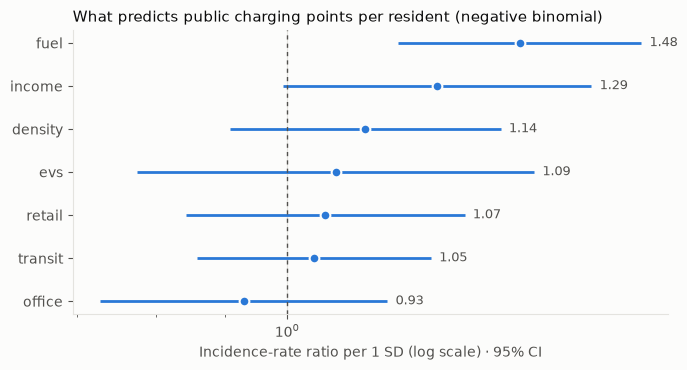

In [18]:
def irr_table(res, cols=X_COLS):
    ci = res.conf_int().loc[cols]
    return pd.DataFrame({"IRR": np.exp(res.params[cols]),
                         "ci_low": np.exp(ci[0]), "ci_high": np.exp(ci[1]),
                         "p_value": res.pvalues[cols]})

irr = irr_table(nb)
irr_pois = irr_table(pois)
print(irr.round(3).to_string())

# Coefficient plot (one series; the title names it)
order = irr.sort_values("IRR").index
fig, ax = plt.subplots(figsize=(7, 3.8))
ypos = np.arange(len(order))
ax.hlines(ypos, irr.loc[order, "ci_low"], irr.loc[order, "ci_high"], color=BLUE, linewidth=2)
ax.plot(irr.loc[order, "IRR"], ypos, "o", color=BLUE, markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.axvline(1, color=INK_2, linewidth=1, linestyle=(0, (3, 3)))
ax.set_xscale("log")
ax.set_yticks(ypos, order)
ax.set_xlabel("Incidence-rate ratio per 1 SD (log scale) · 95% CI")
ax.set_title("What predicts public charging points per resident (negative binomial)", loc="left", fontsize=11)
for yi, name in zip(ypos, order):
    ax.annotate(f"{irr.loc[name, 'IRR']:.2f}", (irr.loc[name, "ci_high"], yi),
                xytext=(6, 0), textcoords="offset points", va="center", color=INK_2, fontsize=9)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig("maps/03_irr_coefficients.png", dpi=200)
plt.show()

## 5 · Diagnostics: fit and residuals

In [19]:
df["expected"] = nb.predict(df, offset=df["log_pop"])
mu, n_nb = df["expected"], 1 / alpha
df["pearson_resid"] = (y - mu) / np.sqrt(mu + alpha * mu ** 2)

# Probability of seeing this few points (or fewer) if the municipality behaved like its peers
p_nb = n_nb / (n_nb + mu)
df["p_shortfall"] = stats.nbinom.cdf(y, n_nb, p_nb)

big = df["pearson_resid"].abs() > 2
print(f"|Pearson residual| > 2: {big.sum()} municipalities ({big.mean():.0%}; ~5% expected under a good fit)")
print(df.loc[big, ["name", "population", RESPONSE, "expected", "pearson_resid"]]
        .sort_values("pearson_resid").round(2).to_string(index=False))

|Pearson residual| > 2: 9 municipalities (5%; ~5% expected under a good fit)
                                        name  population  public_points  expected  pearson_resid
                               Navalagamella        3169              6      1.35           2.77
                               Arroyomolinos       38075            149     42.32           2.78
               Lozoyuela-Navas-Sieteiglesias        1468             10      2.07           3.38
                          Berzosa del Lozoya         242              2      0.18           3.94
                                     Redueña         288              2      0.17           4.10
                                     Braojos         233              2      0.15           4.52
Gargantilla del Lozoya y Pinilla de Buitrago         396              4      0.26           6.65
                       San Martín de la Vega       21010             94     12.27           7.10
                         Puebla de la Sierra      

### The README hypothesis: north-west corridor vs dense southern municipalities

Observed vs expected points for the municipalities named in the README. Ratio < 1 = fewer points than peers with
the same fundamentals. `p_shortfall` is the probability of a count this low or lower if the municipality behaved
like its peers (small = genuinely unusual, not noise).

In [20]:
GROUPS = {
    "North-west": {"28115": "Pozuelo de Alarcón", "28080": "Majadahonda", "28127": "Las Rozas de Madrid"},
    "South":      {"28074": "Leganés", "28065": "Getafe", "28058": "Fuenlabrada",
                   "28007": "Alcorcón", "28092": "Móstoles"},
}
code_to_group = {c: g for g, d in GROUPS.items() for c in d}
df["group"] = df["ine_code"].map(code_to_group).fillna("Other")

hyp = df[df["group"] != "Other"][["group", "name", "population", RESPONSE, "expected", "p_shortfall"]].copy()
hyp["ratio"] = hyp[RESPONSE] / hyp["expected"]
print(hyp.sort_values(["group", "ratio"]).round(3).to_string(index=False))

agg = hyp.groupby("group")[[RESPONSE, "expected"]].sum()
agg["ratio"] = agg[RESPONSE] / agg["expected"]
print("\nGroup totals (observed / expected):")
print(agg.round(2).to_string())

     group                name  population  public_points  expected  p_shortfall  ratio
North-west  Pozuelo de Alarcón       89770            193   251.580        0.510  0.767
North-west Las Rozas de Madrid       99037            191   165.085        0.680  1.157
North-west         Majadahonda       73625            232   128.101        0.847  1.811
     South            Móstoles      214817            110   157.899        0.473  0.697
     South              Getafe      193238            184   190.250        0.606  0.967
     South         Fuenlabrada      190076            139   141.083        0.614  0.985
     South            Alcorcón      175719            275   182.355        0.784  1.508
     South             Leganés      195734            261   167.511        0.796  1.558

Group totals (observed / expected):
            public_points  expected  ratio
group                                     
North-west            616    544.77   1.13
South                 969    839.10   1.15

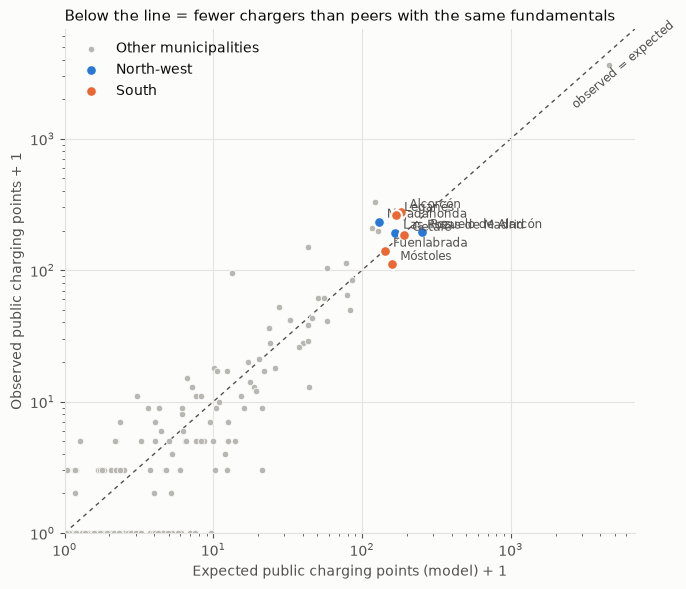

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
other = df["group"] == "Other"
ax.scatter(df.loc[other, "expected"] + 1, df.loc[other, RESPONSE] + 1, s=22, color=CONTEXT,
           edgecolor=SURFACE, linewidth=0.6, label="Other municipalities", zorder=2)
for g, colr in (("North-west", BLUE), ("South", ORANGE)):
    m = df["group"] == g
    ax.scatter(df.loc[m, "expected"] + 1, df.loc[m, RESPONSE] + 1, s=60, color=colr,
               edgecolor=SURFACE, linewidth=1.5, label=g, zorder=3)
    for _, r in df[m].iterrows():
        ax.annotate(r["name"], (r["expected"] + 1, r[RESPONSE] + 1), xytext=(6, 3),
                    textcoords="offset points", fontsize=8.5, color=INK_2)
lim = [1, max(df["expected"].max(), y.max()) * 1.5]
ax.plot(lim, lim, color=INK_2, linewidth=1, linestyle=(0, (3, 3)), zorder=1)
ax.annotate("observed = expected", (lim[1] / 3, lim[1] / 3), xytext=(4, -12), textcoords="offset points",
            fontsize=8.5, color=INK_2, rotation=40)
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim,
       xlabel="Expected public charging points (model) + 1", ylabel="Observed public charging points + 1")
ax.set_title("Below the line = fewer chargers than peers with the same fundamentals", loc="left", fontsize=11)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("maps/03_observed_vs_expected.png", dpi=200)
plt.show()

### Spatial autocorrelation of residuals (optional)
If neighbouring municipalities have similar residuals (Moran's I > 0, small p), the model is missing a spatial
pattern: a reason to try the GWR stretch goal. Needs `pip install libpysal esda`.

In [22]:
try:
    import geopandas as gpd
    from libpysal.weights import Queen
    from esda.moran import Moran

    geo = gpd.read_file(OUT / "features_municipal.gpkg")[["ine_code", "geometry"]]
    geo = geo.merge(df[["ine_code", "pearson_resid"]], on="ine_code")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        w = Queen.from_dataframe(geo, use_index=False)
    w.transform = "r"
    mi = Moran(geo["pearson_resid"], w, permutations=999)
    print(f"Moran's I of Pearson residuals = {mi.I:.3f}, permutation p = {mi.p_sim:.3f}")
except ImportError:
    print("libpysal / esda not installed; skipping. Run: %pip install libpysal esda")

Moran's I of Pearson residuals = 0.011, permutation p = 0.327


## 6 · Robustness

The same NB model refitted several ways. If an effect keeps its direction and rough size across columns, trust it.
- **without fleet municipalities**: drops the 19 where EVs were imputed (removes the income→EV circularity)
- **without Madrid city**: one municipality holds ~45% of the points; checks it isn't driving everything
- **sites, not points**: counts locations instead of plugs
- **without income / without evs**: the two are correlated, so each is also tested alone. If they share the effect,
  the honest reading is "affluent, EV-owning municipalities", not one of the two specifically

In [23]:
flag = df["fleet_domicile_flag"].astype(str).str.lower().isin(["true", "1"])
variants = {
    "main":            nb,
    "no fleet munis":  fit_nb(FORMULA, df[~flag]),
    "no Madrid city":  fit_nb(FORMULA, df[df["ine_code"] != "28079"]),
    "sites not points": fit_nb(FORMULA.replace(RESPONSE, "public_sites", 1), df),
}
# income and evs are correlated (EV adoption rises steeply with income); refit with each one alone
for drop in ("income", "evs"):
    f = FORMULA.replace(f" + {drop}", "").replace(f"~ {drop} + ", "~ ")
    variants[f"without {drop}"] = fit_nb(f, df)
rob = pd.DataFrame({k: np.exp(v.params.reindex(X_COLS)) for k, v in variants.items()}).round(2)
sig = pd.DataFrame({k: v.pvalues.reindex(X_COLS) < 0.05 for k, v in variants.items()})
print("IRR per 1 SD (* = p < 0.05)")
tab = rob.map(lambda v: "–" if pd.isna(v) else f"{v:.2f}")
print(tab.where(~sig, tab + "*").to_string())
print("\nn:", {k: int(v.nobs) for k, v in variants.items()})
print("alpha:", {k: round(float(v.params["alpha"]), 3) for k, v in variants.items()})

IRR per 1 SD (* = p < 0.05)
          main no fleet munis no Madrid city sites not points without income without evs
income    1.29           1.23           1.29            1.26*              –       1.35*
density   1.14           1.13           1.14             0.98           1.16        1.14
evs       1.09           1.11           1.08             0.99          1.40*           –
retail    1.07           1.16           1.07             1.02           1.08        1.06
office    0.93           0.94           0.93             0.98           1.01        0.92
transit   1.05           1.08           1.05             0.95           1.05        1.04
fuel     1.48*          1.50*          1.48*            1.63*          1.48*       1.48*

n: {'main': 179, 'no fleet munis': 160, 'no Madrid city': 178, 'sites not points': 179, 'without income': 179, 'without evs': 179}
alpha: {'main': 0.798, 'no fleet munis': 0.81, 'no Madrid city': 0.814, 'sites not points': 0.071, 'without income': 0.816, 'wit

## 7 · Save

In [24]:
pred = df[["ine_code", "name", "population", RESPONSE, "public_sites", "expected",
           "pearson_resid", "p_shortfall", "fleet_domicile_flag", "group"]].copy()
pred["gap_points"] = pred["expected"] - pred[RESPONSE]          # > 0: fewer than expected
pred["ratio_obs_exp"] = pred[RESPONSE] / pred["expected"]
pred.to_csv(OUT / "model_predictions.csv", index=False)

coefs = irr.join(irr_pois.add_suffix("_poisson")).join(vif)
coefs.loc["alpha", "IRR"] = alpha
coefs.to_csv(OUT / "model_coefficients.csv")

print("Largest shortfalls in points (expected − observed):")
print(pred.nlargest(15, "gap_points")[["name", "population", RESPONSE, "expected", "ratio_obs_exp", "p_shortfall"]]
          .round(2).to_string(index=False))
print(f"\nSaved {OUT / 'model_predictions.csv'} and {OUT / 'model_coefficients.csv'}")

Largest shortfalls in points (expected − observed):
                   name  population  public_points  expected  ratio_obs_exp  p_shortfall
                 Madrid     3506730           3664   4557.60           0.80         0.53
     Pozuelo de Alarcón       89770            193    251.58           0.77         0.51
     Boadilla del Monte       66349            102    155.00           0.66         0.45
               Móstoles      214817            110    157.90           0.70         0.47
                  Parla      137471             49     81.95           0.60         0.42
San Fernando de Henares       39059             12     42.86           0.28         0.21
              Alpedrete       15686              2     20.18           0.10         0.10
         Colmenar Viejo       58730             40     57.16           0.70         0.48
              Valdemoro       85972             64     78.57           0.81         0.54
   Villaviciosa de Odón       30127             28     42.

### Notes for the report
- **Peer benchmark, not demand.** Expected counts come from how supply relates to fundamentals *across the Comunidad*.
  A region-wide shortage is invisible to this model.
- **Supply follows demand and vice versa.** POI predictors (retail, offices) partly reflect where operators already chose
  to build; coefficients are associations, not causal effects.
- **EV variable.** Fleet-corrected (`evs_per_1k_pop_adj`); see the robustness column without the 19 fleet municipalities.
- **Parking proxy.** Density stands in for "% dwellings without private parking" (not published for all municipalities).